# Research01 Baseline Pipeline

이 노트북은 생성 anomaly를 사용하지 않는 원본 데이터 기반 `RandomForestClassifier` baseline을 계산합니다.

이번 버전에서는 두 가지 baseline을 함께 확인합니다.

1. 기본 RandomForest baseline
2. Research04에서 선택된 RandomForest 하이퍼파라미터를 원본 데이터 baseline에 적용한 결과

즉, Research04의 성능 향상이 생성 anomaly 때문인지, 또는 RandomForest 하이퍼파라미터/threshold 조정 때문인지 비교할 수 있게 합니다.

In [1]:
from pathlib import Path
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

SCRIPT_PATH = ROOT / "tools" / "research01_randomforest_baseline.py"
RESULT_DIR = ROOT / "data" / "research01" / "results"
FIGURE_DIR = ROOT / "data" / "research01" / "figures"
RESEARCH03_RESULT_DIR = ROOT / "data" / "research03" / "results"

print("ROOT:", ROOT)
print("script exists:", SCRIPT_PATH.exists())

ROOT: c:\Users\gram\Desktop\Research
script exists: True


## 1. Baseline 실행

아래 셀은 원본 정상 데이터와 원본 anomaly seed만 사용해 baseline을 학습합니다. 생성 anomaly는 사용하지 않습니다.

스크립트는 기본 RandomForest baseline과 하이퍼파라미터 적용 baseline을 모두 저장합니다.

In [2]:
result = subprocess.run(
    [sys.executable, str(SCRIPT_PATH)],
    cwd=ROOT,
    text=True,
    capture_output=True,
)

print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("Research01 RandomForest baseline failed")

              method                   model  ...  true_normal  true_anomaly
0  Real anomaly only  RandomForestClassifier  ...         2785           296

[1 rows x 17 columns]

                                         method  ... true_anomaly
0  Real anomaly only + tuned RF hyperparameters  ...          296

[1 rows x 17 columns]

              precision    recall  f1-score   support

      normal       0.96      0.99      0.97      2785
     anomaly       0.86      0.62      0.72       296

    accuracy                           0.95      3081
   macro avg       0.91      0.80      0.85      3081
weighted avg       0.95      0.95      0.95      3081


              precision    recall  f1-score   support

      normal       0.98      1.00      0.99      2785
     anomaly       0.98      0.79      0.88       296

    accuracy                           0.98      3081
   macro avg       0.98      0.90      0.93      3081
weighted avg       0.98      0.98      0.98      3081




## 2. Baseline 성능

`randomforest_original_baseline.csv`는 기존 기본 설정 baseline이고, `randomforest_hyperparameter_applied_baseline.csv`는 Research04에서 사용한 RandomForest 하이퍼파라미터를 원본 데이터 baseline에 적용한 결과입니다.

In [3]:
metric_cols = [
    "method",
    "normal_train_used",
    "real_anomaly_seed_used",
    "generated_anomaly_used",
    "threshold_selected_on_real_validation",
    "precision",
    "recall",
    "f1",
    "auroc",
    "auprc",
    "pred_anomaly",
]

baseline_df = pd.read_csv(RESULT_DIR / "randomforest_original_baseline.csv")
tuned_baseline_df = pd.read_csv(RESULT_DIR / "randomforest_hyperparameter_applied_baseline.csv")
baseline_compare_df = pd.concat([baseline_df, tuned_baseline_df], ignore_index=True)

display(baseline_compare_df[metric_cols].round(4))

,method,normal_train_used,real_anomaly_seed_used,generated_anomaly_used,threshold_selected_on_real_validation,precision,recall,f1,auroc,auprc,pred_anomaly
0,Real anomaly only,5000,247,0,0.91,0.8551,0.6182,0.7176,0.9589,0.7999,214
1,Real anomaly only + tuned RF hyperparameters,5000,247,0,0.81,0.9833,0.7939,0.8785,0.9930,0.9540,239


## 3. Research04 결과와 비교

Research04의 최종 추천 결과는 `Diffusion 1000 + 튜닝된 RandomForest + threshold 0.78`입니다. 아래 셀은 원본 데이터만 사용한 하이퍼파라미터 baseline과 Research04 결과를 직접 비교합니다.

In [4]:
research04_strategy_path = RESEARCH03_RESULT_DIR / "diffusion1000_tuned_threshold_strategy_comparison.csv"

if research04_strategy_path.exists():
    research04_df = pd.read_csv(research04_strategy_path)
    selected_research04 = research04_df.loc[
        research04_df["strategy"].str.startswith("max_recall_with_validation_precision")
    ].iloc[0]

    base = tuned_baseline_df.iloc[0]
    comparison_df = pd.DataFrame([
        {
            "experiment": "Research01 tuned baseline (no generated data)",
            "generated_anomaly_used": int(base["generated_anomaly_used"]),
            "threshold": base["threshold_selected_on_real_validation"],
            "precision": base["precision"],
            "recall": base["recall"],
            "f1": base["f1"],
            "auprc": base["auprc"],
            "pred_anomaly": int(base["pred_anomaly"]),
        },
        {
            "experiment": "Research04 Diffusion 1000 tuned RF + threshold optimization",
            "generated_anomaly_used": 1000,
            "threshold": selected_research04["threshold"],
            "precision": selected_research04["final_precision"],
            "recall": selected_research04["final_recall"],
            "f1": selected_research04["final_f1"],
            "auprc": selected_research04["final_auprc"],
            "pred_anomaly": int(selected_research04["final_pred_anomaly"]),
        },
    ])
    display(comparison_df.round(4))
else:
    print("Research04 result not found:", research04_strategy_path)

,experiment,generated_anomaly_used,threshold,precision,recall,f1,auprc,pred_anomaly
0,Research01 tuned baseline (no generated data),0,0.81,0.9833,0.7939,0.8785,0.954,239
1,Research04 Diffusion 1000 tuned RF + threshold...,1000,0.78,0.8429,0.8885,0.8651,0.961,312


## 4. 해석

하이퍼파라미터를 적용한 원본 baseline은 생성 데이터를 쓰지 않아도 성능이 크게 올라갑니다. 따라서 Research04 결과를 해석할 때는 단순히 생성 anomaly 추가 효과만 보지 말고, 하이퍼파라미터와 threshold 조정 효과도 분리해서 봐야 합니다.

현재 결과에서는 Research04가 recall을 더 높이는 방향으로 유리하고, Research01 하이퍼파라미터 baseline은 precision과 F1이 더 높게 나옵니다.

## 5. Confusion Matrix

아래 그림은 기본 baseline과 하이퍼파라미터 적용 baseline의 confusion matrix입니다.

randomforest_original_baseline_confusion_matrix.png


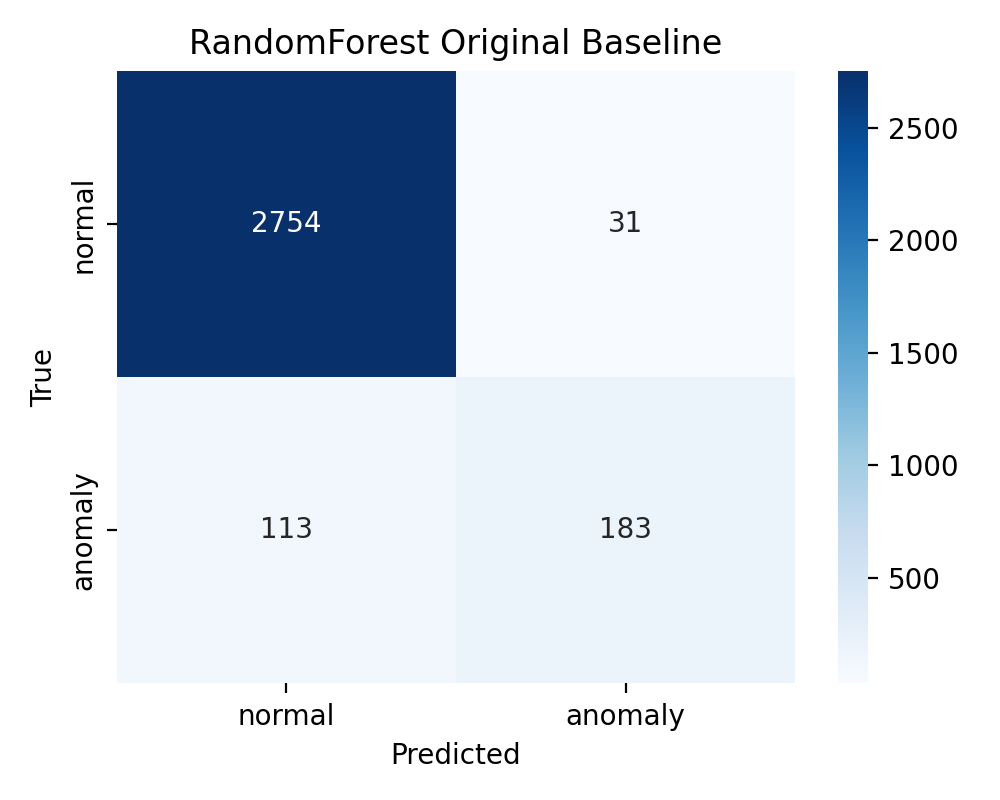

randomforest_hyperparameter_applied_baseline_confusion_matrix.png


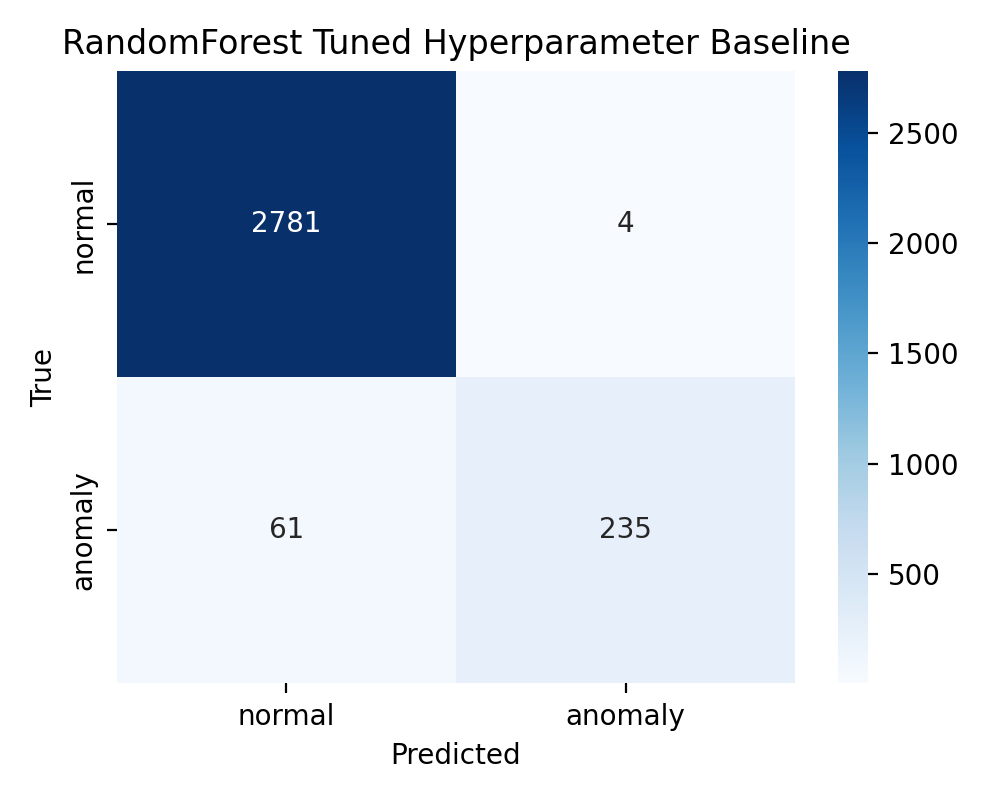

In [5]:
for figure_name in [
    "randomforest_original_baseline_confusion_matrix.png",
    "randomforest_hyperparameter_applied_baseline_confusion_matrix.png",
]:
    figure_path = FIGURE_DIR / figure_name
    print(figure_name)
    if figure_path.exists():
        display(Image(filename=str(figure_path)))
    else:
        print("figure not found:", figure_path)